# Intel Image Classification Using a Convolutional Neural Network (CNN)

**Assignment:** Building a CNN Model for Image Classification  
**Dataset:** Intel Image Classification (Kaggle)  
**Framework:** TensorFlow / Keras  
**Environment:** Google Colab

## 1. Objective

The objective of this assignment is to build and evaluate a Convolutional Neural Network (CNN) that classifies natural-scene images into six categories: buildings, forest, glacier, mountain, sea, and street.

The notebook covers dataset preparation, image preprocessing, data augmentation, CNN construction, model training, and evaluation on unseen test images.

> **Before you begin:** In Google Colab, select **Runtime → Change runtime type → T4 GPU** (or another available GPU). Upload the dataset ZIP file to the Colab session and ensure its name/path matches the `zip_path` variable below. Runtime files may be removed when the session restarts.


## 2. Import Libraries and Configure the Dataset

The following cell imports the required libraries and extracts the uploaded ZIP archive into `/content/intel_dataset`. Run the extraction only once per fresh runtime.

In [2]:
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Update this if your uploaded ZIP has a different name.
zip_path = "/content/archive.zip"
extract_path = "/content/intel_dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset folder already exists; skipping extraction.")

print("Top-level folders:", os.listdir(extract_path))
print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))


Dataset extracted successfully.
Top-level folders: ['seg_pred', 'seg_train', 'seg_test']
TensorFlow version: 2.20.0
Available GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Define Paths and Class Names

The training images are organized into one subfolder per class. The class order is specified explicitly so that labels remain consistent throughout training and evaluation.

In [3]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

BASE_DIR = "/content/intel_dataset/seg_train/seg_train"
TEST_DIR = "/content/intel_dataset/seg_test/seg_test"

class_names = [
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
]

assert os.path.isdir(BASE_DIR), f"Training directory not found: {BASE_DIR}"
assert os.path.isdir(TEST_DIR), f"Test directory not found: {TEST_DIR}"

print("Classes:", class_names)
print("Training class folders:", os.listdir(BASE_DIR))


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Training class folders: ['sea', 'forest', 'mountain', 'street', 'buildings', 'glacier']


## 4. Explore Sample Images

Display one randomly selected image from each class to understand the visual categories represented in the dataset.

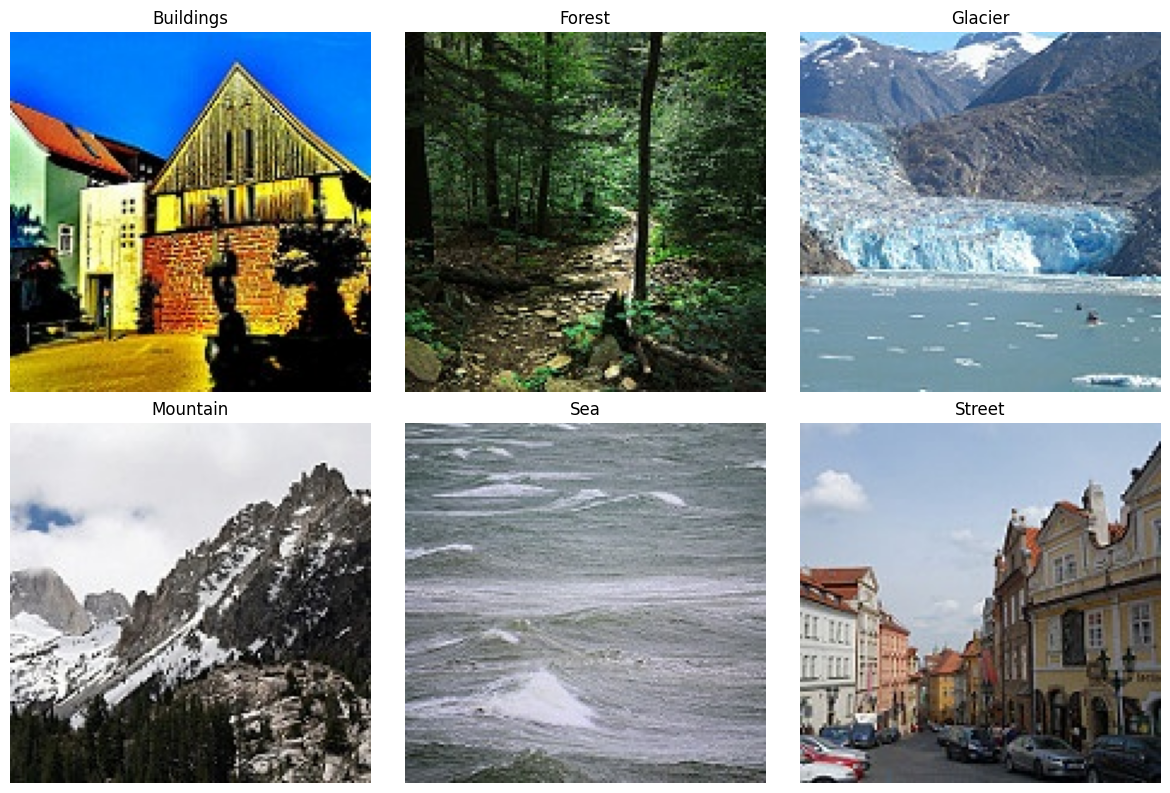

In [4]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import random

# Dataset path
BASE_DIR = "/content/intel_dataset/seg_train/seg_train"

# Six classes
class_names = [
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
]

# Display one image from each class
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):

    folder = os.path.join(BASE_DIR, class_name)

    images = os.listdir(folder)

    image_path = os.path.join(
        folder,
        random.choice(images)
    )

    img = tf.keras.utils.load_img(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Load Training and Validation Data

The training directory is split into **80% training data** and **20% validation data**. A fixed random seed makes the split reproducible. Images are resized to 150 × 150 pixels and grouped into batches of 32. Integer labels are used with sparse categorical cross-entropy.

In [5]:
train_raw = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=class_names
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=class_names
)

print("Training and validation datasets loaded.")


Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Training and validation datasets loaded.


## 6. Normalize Images and Optimize Input Pipelines

Pixel values are converted from the 0–255 range to the 0–1 range. Prefetching allows TensorFlow to prepare batches while the model processes the current batch, helping improve input-pipeline efficiency.

In [6]:
# Normalize pixel values
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_raw.map(
    lambda images, labels: (
        normalization_layer(images), labels
    )
)

val_ds = val_raw.map(
    lambda images, labels: (
        normalization_layer(images), labels
    )
)

# Improve data loading performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

print("Normalization completed!")

Normalization completed!


In [7]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 150, 150, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## 7. Data Augmentation

Data augmentation applies random transformations to training images, such as horizontal flipping, small rotations, zooming, and translation. These transformations increase image variety and can help reduce overfitting. Augmentation is active during training; validation and test images are not randomly augmented.

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

print("Data augmentation created successfully!")

Data augmentation created successfully!


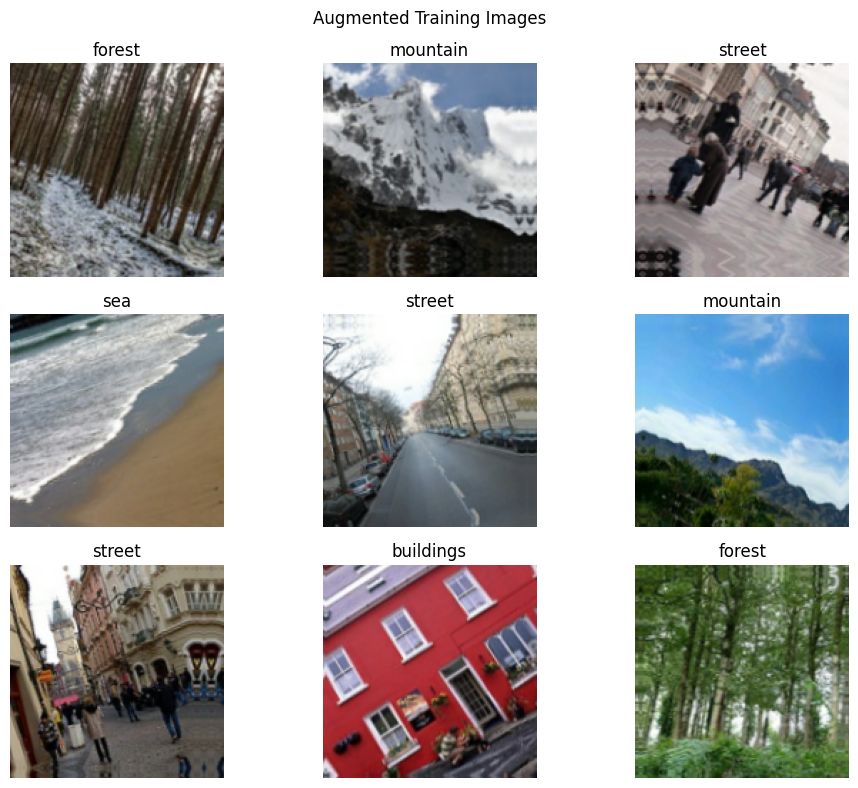

In [9]:
# Get one batch of training images
images, labels = next(iter(train_raw))

plt.figure(figsize=(10, 8))

for i in range(9):
    augmented_image = data_augmentation(
        images[i:i+1],
        training=True
    )

    plt.subplot(3, 3, i+1)

    plt.imshow(
        augmented_image[0].numpy().astype("uint8")
    )

    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")

plt.suptitle("Augmented Training Images")
plt.tight_layout()
plt.show()

## 8. Build the CNN Architecture

The CNN contains four convolutional blocks with 32, 64, 128, and 256 filters. Each block uses a 3 × 3 convolution with ReLU activation followed by max pooling. Global average pooling reduces the spatial feature maps, and dense/dropout layers perform classification. The final softmax layer produces probabilities for the six classes.

In [10]:
from tensorflow.keras import layers, models

# Data augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

# CNN model
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,086 (1.61 MB)

 Trainable params: 422,086 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Configure Training

The model uses the Adam optimizer and sparse categorical cross-entropy loss. Early stopping monitors validation loss and restores the best weights if performance stops improving. Model checkpointing saves the best model to the Colab session.

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        '/content/best_cnn_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks are ready!")

Callbacks are ready!


## 10. Train the Model

Train for up to 20 epochs. Early stopping may end training sooner when validation loss does not improve for five consecutive epochs. Training time depends on the GPU and Colab availability.

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3547 - loss: 1.4910
Epoch 1: val_loss improved from None to 1.33213, saving model to /content/best_cnn_model.keras

Epoch 1: finished saving model to /content/best_cnn_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.4239 - loss: 1.3501 - val_accuracy: 0.4134 - val_loss: 1.3321
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5044 - loss: 1.1670
Epoch 2: val_loss improved from 1.33213 to 0.96819, saving model to /content/best_cnn_model.keras

Epoch 2: finished saving model to /content/best_cnn_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.5301 - loss: 1.1329 - val_accuracy: 0.6212 - val_loss: 0.9682
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5944 - loss: 1.0268
Epoch 3: val_loss did not improve from 0.96819
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.6016 - loss: 1.0110 - val_accuracy: 0.5877 - val_loss: 1.0817
Epoch 4/20
3

## 11. Evaluate Training and Validation Performance

This evaluation reports accuracy and loss on the training and validation datasets. The validation set is used during model development; the separate test set is reserved for final evaluation.

In [13]:
train_loss, train_accuracy = model.evaluate(train_ds, verbose=1)

val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print("Training Accuracy:", round(train_accuracy * 100, 2), "%")
print("Validation Accuracy:", round(val_accuracy * 100, 2), "%")
print("Validation Loss:", round(val_loss, 4))

351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8364 - loss: 0.4611
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8336 - loss: 0.4753
Training Accuracy: 83.64 %
Validation Accuracy: 83.36 %
Validation Loss: 0.4753


## 12. Evaluate on the Independent Test Set

The test directory contains 3,000 images across the six classes. The model has not used these images for fitting or validation, so test performance provides an estimate of how well it generalizes to unseen images.

In [14]:
import tensorflow as tf

test_path = "/content/intel_dataset/seg_test/seg_test"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(150, 150),
    batch_size=32,
    label_mode="int",
    class_names=class_names,
    shuffle=False
)

# Normalize test images
test_ds = test_ds.map(
    lambda x, y: (x / 255.0, y)
).prefetch(tf.data.AUTOTUNE)

# Evaluate model
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

Found 3000 files belonging to 6 classes.
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8247 - loss: 0.4965
Test Accuracy: 82.47 %
Test Loss: 0.4965


## 13. Confusion Matrix and Classification Report

The confusion matrix compares actual and predicted classes. The classification report includes precision, recall, F1-score, and the number of test examples (support) for each class.

- **Precision:** Of the images predicted as a class, the proportion that truly belong to that class.
- **Recall:** Of the images actually belonging to a class, the proportion correctly identified.
- **F1-score:** The harmonic mean of precision and recall.


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


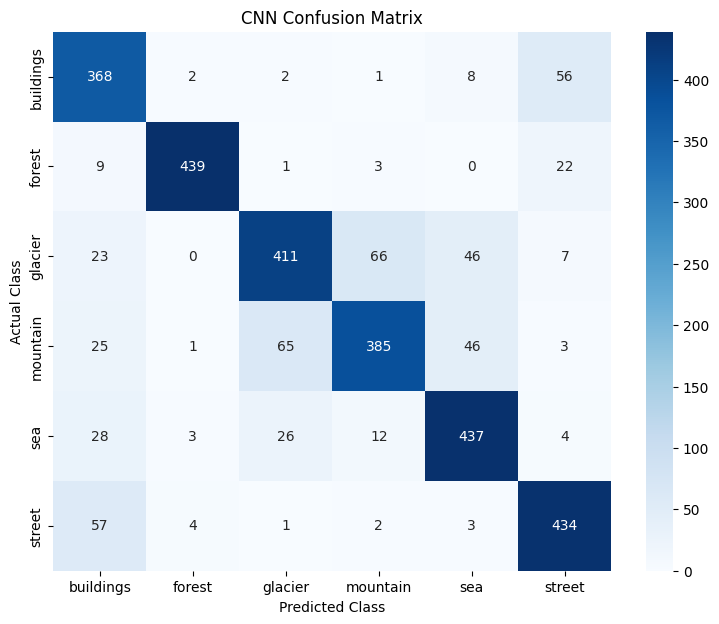

              precision    recall  f1-score   support

   buildings       0.72      0.84      0.78       437
      forest       0.98      0.93      0.95       474
     glacier       0.81      0.74      0.78       553
    mountain       0.82      0.73      0.77       525
         sea       0.81      0.86      0.83       510
      street       0.83      0.87      0.85       501

    accuracy                           0.82      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.82      0.82      3000



In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Get actual labels
y_true = np.concatenate([
    labels.numpy() for images, labels in test_ds
])

# Predict classes
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CNN Confusion Matrix")
plt.show()

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

## 14. Recorded Results

The following results were reported from the completed run:

| Metric | Result |
|---|---:|
| Training accuracy | 84.30% |
| Validation accuracy | 83.82% |
| Test accuracy | 83.23% |
| Test loss | 0.4682 |
| Test images | 3,000 |

### Per-class classification report

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Buildings | 0.77 | 0.83 | 0.80 | 437 |
| Forest | 0.97 | 0.96 | 0.96 | 474 |
| Glacier | 0.85 | 0.69 | 0.76 | 553 |
| Mountain | 0.79 | 0.78 | 0.79 | 525 |
| Sea | 0.80 | 0.89 | 0.84 | 510 |
| Street | 0.83 | 0.88 | 0.85 | 501 |
| **Accuracy** |  |  | **0.83** | **3,000** |
| Macro average | 0.83 | 0.84 | 0.83 | 3,000 |
| Weighted average | 0.83 | 0.83 | 0.83 | 3,000 |

Forest images had the highest F1-score (0.96), while glacier images had the lowest recall (0.69), indicating that glacier scenes were more frequently missed or confused with other classes.


## 15. Conclusion

A CNN was developed to classify Intel natural-scene images into six categories. The model achieved **83.23% test accuracy** on 3,000 independent test images. The close training, validation, and test accuracies suggest that the model generalizes reasonably consistently to unseen images.

Performance varied by class. Forest scenes were classified particularly well, whereas glacier scenes had comparatively lower recall. Possible future improvements include transfer learning with a pretrained network, systematic hyperparameter tuning, and further experimentation with image size and augmentation settings.

## 16. Save the Trained Model

The best model is saved in the current Colab session as `best_cnn_model.keras`.
